**Succesive Overrelaxation (SOR)**

This method effectively uses the Jacobi solution values as a 'correction'; that is, the potential at each point has its Jacobi (or, perhaps more specifically, the Gauss-Seidel variation of it) value found, and this is scaled and added to the current value at that point.

Note that this method will only converge if the corresponding matrix, which simply represents the coefficents of all of the individual equations for each point (detailed more in the relevant report), is symmetric and positive-definite (or diagonally-dominant).

In [1]:
# Imports for the traditional numerical solution

import numpy as np
import matplotlib.pyplot as plt
import time

**Set up:**

Creates the grid used by the numerical solution, and the source term value at each point for Poisson's equation (Laplace's equation has a source of 0 at each point, and so it need not be calculated).

In [2]:
# ~Set up~

# constants
q_e = -1.602E-19
epsilon_0 = 8.85E-12
k = 1 / (4 * np.pi * epsilon_0)

# Domain:
N = 150 # number of points along an edge; does count 0
num_pts = N*N + 2*N + 1 # Points along all edges, and evenly spaced betwen. 
L = 1 # the total side length of the square
dL = L/N # distance between each discrete 'point'

# building the plane, if you will. X holds x coords, Y holds y coords, for the same index i
# that is; (x, y) = (X(i), Y(j)) at the ijth point 
x = np.linspace(0, 1, N + 1) * L
y = np.linspace(0, 1, N + 1) * L
X, Y = np.meshgrid(x, y)

print('Grid complete!')
print('Size:', X.shape)
print('Length per section (dx):', dL, 'm')

#print(plane)


# Next, find the value of the source term at each point for poissons:
f_values = -10 * np.exp(-100*((X - 0.5)**2 + (Y - 0.5)**2))
print('Source terms complete!')

# u values depend on the eq, and thus are found in their respective sections

# Two planes of coordinate values that form the points of the actual 2d plane
# one 'x-plane' and one 'y-plane'; the same index applied to both gets you the
# actual point.

Grid complete!
Size: (151, 151)
Length per section (dx): 0.006666666666666667 m
Source terms complete!


**Laplace Equation (source is zero):**

An application of the SOR method to Laplace's equation. There is also an analytical solution for this one, against which the SOR solution may be compared. The analytical solution is an infinite series, and so it is approximated with the first 100 terms. 

In [9]:
# ~Laplace variantion~
# really, a special case of poissons where there is no charge in the area. thus, rho = 0

# At a basic level, Jacobi method; effectively, you iterate over the plane, and each time take a sort of weighted average
# for each point with its neighbors from the previous iteration and the source function. This comes
# from the discrete version of poissons eq.; (4*U(ij) - (neighbors previous U values) = - f(i,j)*dL^2.
# Gauss-Seidel is an improvement on this, used here, where you dont make a distinction between iterations;
# you simply use whatever the newest value at a point is.

# This uses a variation/improvement on Jacobi called Succesive Overrelaxation, or (SOR)

# Then define boundaries in u
u_values = np.zeros((N + 1, N + 1))
# top
u_values[:][-1] = 100 # all 'row ends', as it were, are set to 100


m = 0 # number of iterations

w = 2/(1 + np.sin(np.pi/(N+1))) # SOR coefficent; this is the recognized ideal value

err = np.array([])
start = time.time()
# SOR method calculation; effectively Gauss Seidel with 'over-relaxation factor'. 
# really, 'relaxes' the solver so that it can make larger jumps in the direction of the solution
while(u_values[int(N/2)][int(N/2)] < 24.99): # 24.99 in the center is very close to the actual solution, which should have 25. Is asymptotic, though
    for i in range(1, N): # need to not touch the boundaries
        for j in range(1, N):
            u_values[i][j] = u_values[i][j] + w * (u_values[i - 1][j] + u_values[i + 1][j] + u_values[i][j - 1] + u_values[i][j + 1] - 4*u_values[i][j]) / 4 
    m += 1 # just tracking the numer of iterations around the square needed
    err = np.append(err, ((25 - u_values[int(N/2)][int(N/2)])/25) * 100) # this calculates the error, as a percentage at each iteration so it can be plotted
    
finish = time.time()

print('Numerical solution complete!')
print('Number of iterations: ', m)
print(f"Time elapsed:  {(finish - start):.2f} s") 

# Analytical solution
# This can be found using a seperation of variables; it does
# end up being an infinite series. In some sense, for some number 
# of terms included, this is sort of an 'analytical approximation'.

n_f = 200 # number of fourier terms. more accurately, perhaps, highest n, n = 1,3,..., n_f or n_f-1

u_analytic = np.zeros((N + 1, N + 1))
for n in range(1, n_f, 2): # sum of several fourier terms from the solution; only odd
    u_analytic = u_analytic + (400/(n*np.pi)) * (1/np.sinh((n*np.pi))) * np.sin((n*np.pi) * X) * np.sinh((n*np.pi) * Y)

print('Analytic solution complete!')


# SOR gets 292 iterations to get to 24.99 in the center

Numerical solution complete!
Number of iterations:  292
Time elapsed:  11.97 s
Analytic solution complete!


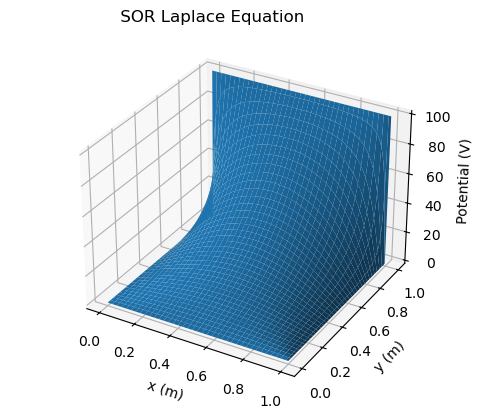

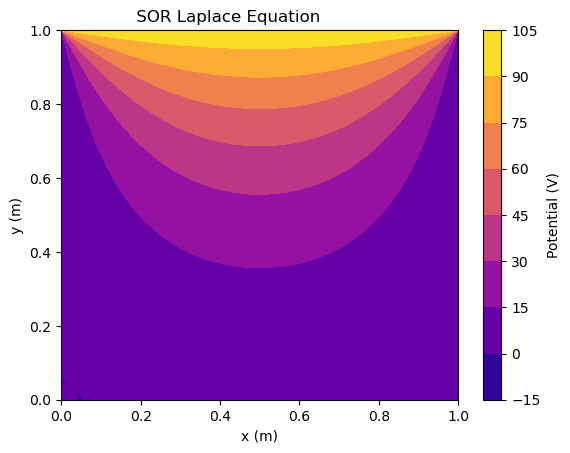

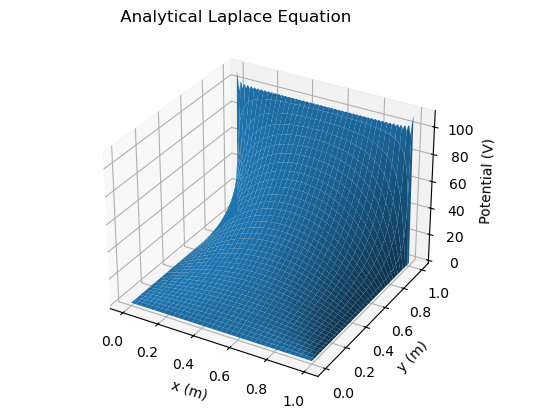

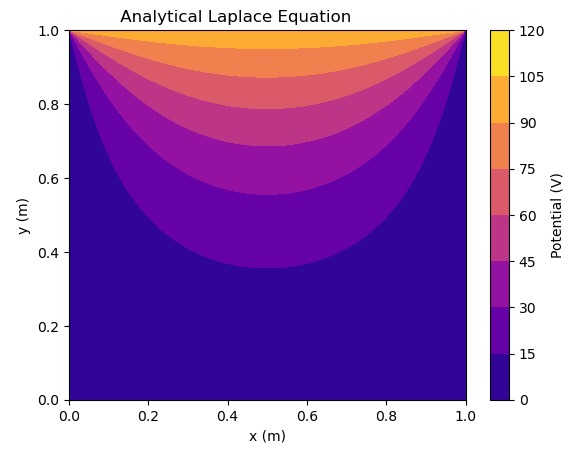

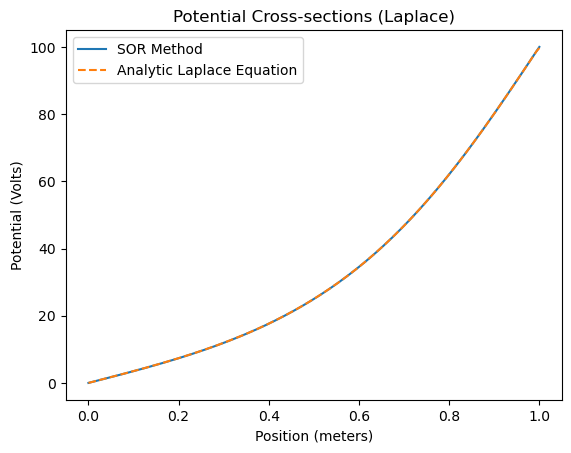

SOR center: 24.990186881878277
Analtic center: 25.000000000000004
(Both centers should be approzimately 25 V)
SOR center error: 0.03925247248690766 %


In [12]:
# ~ plotting ~

# 3d volume plot 
fig = plt.figure()
ax = plt.axes(projection='3d')
ax.plot_surface(X, Y, u_values)
ax.set_title('                     SOR Laplace Equation                                 ') # extra 'padding' to make sure the labels show up
ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
ax.set_zlabel('Potential (V)')
plt.savefig('project1_plots/SOR_Laplace.png')
plt.show()

# contour
ax = plt.axes()
fig = ax.contourf(x, y, u_values, cmap='plasma')
ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
plt.colorbar(fig, orientation='vertical', label='Potential (V)')
ax.set_title('                     SOR Laplace Equation                                 ')
plt.savefig('project1_plots/SOR_Laplace_contour.png')
plt.show()

# ---

# 3d volume plot 
fig = plt.figure()
ax = plt.axes(projection='3d')
ax.plot_surface(X, Y, u_analytic)
ax.set_title('                     Analytical Laplace Equation                                 ')
ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
ax.set_zlabel('Potential (V)')
plt.savefig('project1_plots/Analytic_Laplace.png')
plt.show()

# contour
ax = plt.axes()
fig = ax.contourf(x, y, u_analytic, cmap='plasma')
ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
plt.colorbar(fig, orientation='vertical', label='Potential (V)')
ax.set_title('                     Analytical Laplace Equation                                 ')
plt.savefig('project1_plots/Analytic_Laplace_contour.png')
plt.show()

# cross sectional 2d plot
# a central cross section plot is done for each solution in the project.

cross_sec = X[0] # cross section x

plt.plot(cross_sec , u_values[:, int(N/2)], label="SOR Method") # tuple slicing is necessary here; [i][:] is indistinguishable [:][i]
plt.plot(cross_sec , u_analytic[:, int(N/2)], linestyle='--', label="Analytic Laplace Equation")
plt.title("Potential Cross-sections (Laplace)")
plt.xlabel("Position (meters)")
plt.ylabel("Potential (Volts)")
plt.legend()
plt.savefig('project1_plots/CrossSORAnalytic_Laplace.png')
plt.show()

# The center of the square should have a value equivalent to the average of boundaries. here, ~ 25
sor_center = u_values[int(N/2)][int(N/2)]
an_center = u_analytic[int(N/2)][int(N/2)]

print("SOR center:", sor_center)
print("Analtic center:", an_center)
print("(Both centers should be approzimately 25 V)")
print("SOR center error:", ((an_center - sor_center)/an_center) * 100, '%')

# and they do indeed match this

# These were originally in the form
# 3d volume plot 
#fig = plt.figure(figsize=plt.figaspect(0.4))
#ax1 = fig.add_subplot(1, 2, 1, projection='3d')
#ax1.plot_surface(X, Y, u_values_p)
#ax1.set_title('                     SOR Poisson Equation                     ')
#ax1.set_xlabel('x (m)')
#ax1.set_ylabel('y (m)')
#ax1.set_zlabel('Potential (V)')

# contour
#ax2 = fig.add_subplot(1, 2, 2)
#cntr1 = ax2.contourf(x, y, u_values_p, cmap='plasma')
#ax2.set_xlabel('x (m)')
#ax2.set_ylabel('y (m)')
#fig.colorbar(cntr1, orientation='vertical', label='Potential (V)')
#plt.savefig('project1_plots/SOR_Poisson.png')
#plt.show()

# but this doesn't show up well in the report, and so, for sake of consistancy, i have elected to create
# them seperately. slightly less pretty, but it is indeed worth it!

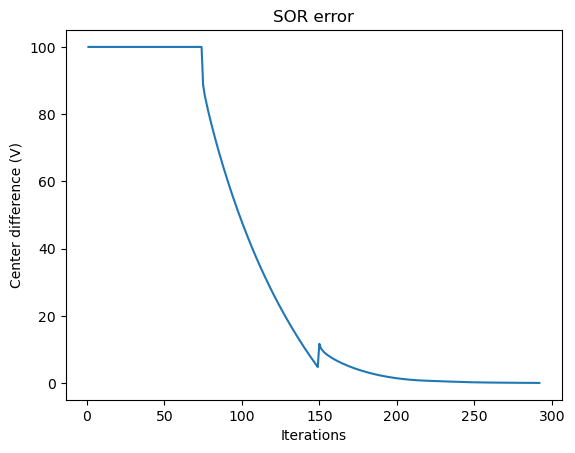

In [5]:
# Error plot

sor_time = np.linspace(1, m, m)

plt.plot(sor_time, err)
plt.title("SOR error")
plt.xlabel("Iterations")
plt.ylabel("Center difference (V)")
plt.savefig('project1_plots/error_analysis_SOR.png')
plt.show()

**Poisson's Equation (using the provided source):**

An application of the SOR method to Poisson's equation, for the given source term (see report or Set up). There isn't as easy a metric for error here, and so the number of iterations is chosen somewhat heuristically. Experimentation shows that the solution tends to converge from this point.

In [6]:
# ~ Poisson's Variation ~

u_values_p = np.zeros((N + 1, N + 1))  # initial guess is 0 everywhere

m = 300 # number of iterations

w = 2/(1 + np.sin(np.pi/(N+1))) # SOR coefficent; this is the recognized ideal value

start = time.time()
# SOR method calculation; effectively Gauss Seidel with 'over-relaxation factor'. 
# really, 'relaxes' the solver so that it can make larger jumps in the direction of the solution
for jac in range(0, m): 
    for i in range(1, N): # need to not touch the boundaries
        for j in range(1, N):
            u_values_p[i][j] = u_values_p[i][j] + w * (u_values_p[i - 1][j] + u_values_p[i + 1][j] + u_values_p[i][j - 1] 
                                                   + u_values_p[i][j + 1] - (f_values[i][j] * dL**2) - (4*u_values_p[i][j])) / 4 # you certainly - f 
finish = time.time()
            
print('Numerical solution complete!')
print('Number of iterations:', m)
print(f"Time elapsed:  {(finish - start):.2f} s")  # forces time to be 2 decimal points

Numerical solution complete!
Number of iterations: 300
Time elapsed:  14.93 s


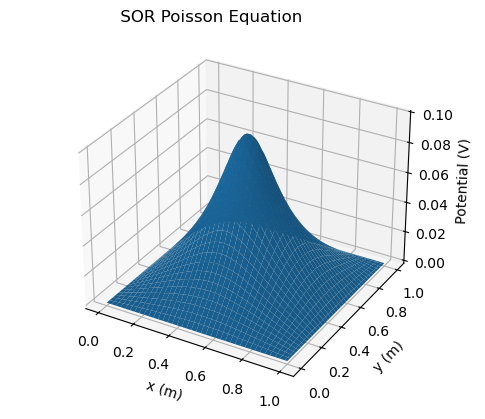

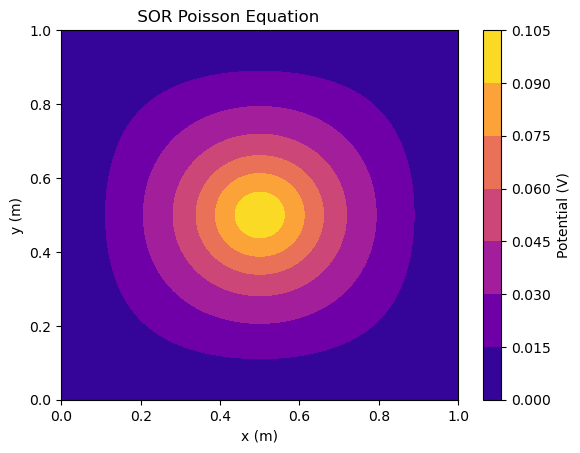

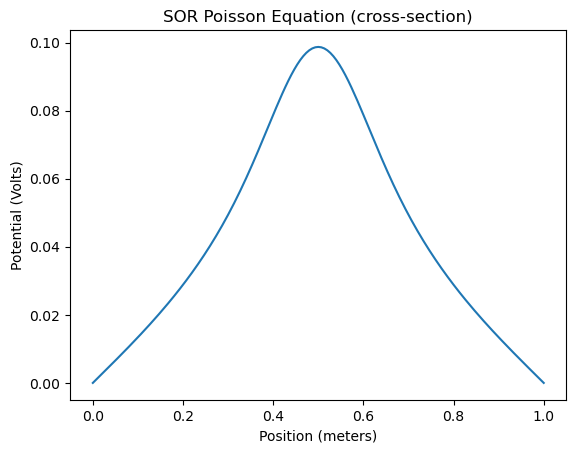

In [11]:
# ~ plotting ~

# 3d volume plot 
fig = plt.figure()
ax = plt.axes(projection='3d')
ax.plot_surface(X, Y, u_values_p)
ax.set_title('                     SOR Poisson Equation                                 ')
ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
ax.set_zlabel('Potential (V)')
plt.savefig('project1_plots/SOR_Poisson.png')
plt.show()

# contour
ax = plt.axes()
fig = ax.contourf(x, y, u_values_p, cmap='plasma')
ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
plt.colorbar(fig, orientation='vertical', label='Potential (V)')
ax.set_title('                     SOR Poisson Equation                                 ')
plt.savefig('project1_plots/SOR_Poisson_contour.png')
plt.show()
# of note: solution is indeed symmetrical

# cross sectional plot
cross_sec = X[0] # cross section x

plt.plot(cross_sec , u_values_p[:, int(N/2)]) # tuple slicing is necessary here; [i][:] is indistinguishable [:][i]
plt.title("SOR Poisson Equation (cross-section)")
plt.xlabel("Position (meters)")
plt.ylabel("Potential (Volts)")
plt.savefig('project1_plots/CrossSOR_Poisson.png')
plt.show()